<h1>Customer Churn<h1>

Amir Lorvand



https://www.kaggle.com/datasets/muhammadshahidazeem/customer-churn-dataset

Customer churn refers to the phenomenon where customers discontinue their relationship or subscription with a company or service provider. It represents the rate at which customers stop using a company's products or services within a specific period. Churn is an important metric for businesses as it directly impacts revenue, growth, and customer retention.

In the context of the Churn dataset, the churn label indicates whether a customer has churned or not. A churned customer is one who has decided to discontinue their subscription or usage of the company's services. On the other hand, a non-churned customer is one who continues to remain engaged and retains their relationship with the company.

Understanding customer churn is crucial for businesses to identify patterns, factors, and indicators that contribute to customer attrition. By analyzing churn behavior and its associated features, companies can develop strategies to retain existing customers, improve customer satisfaction, and reduce customer turnover. Predictive modeling techniques can also be applied to forecast and proactively address potential churn, enabling companies to take proactive measures to retain at-risk customers.

<h4>Description of the variables in the datasets<h4>

Customer ID: Unique identifier for each customer. <br>
Age: The age of the customer. <br>
Gender: The gender of the customer. <br>
Tenure: The number of months the customer has been with the company. <br>
Usage Frequency: How often the customer uses the service. <br>
Support Calls: Number of times the customer has contacted customer support. <br>
Payment Delay: The number of days the customer has delayed payments. <br>
Subscription Type: Type of subscription the customer has. <br>
Contract Length: The duration of the contract. <br>
Total Spend: The total amount the customer has spent on the service. <br>
Last Interaction: The number of days since the customer's last interaction with the company. <br>
Churn: Whether the customer has churned(1=Churned, 0=Retained).

In [ ]:
# ignore all warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import pandas as pd

dataset_1 = pd.read_csv('...')
dataset_2 = pd.read_csv('...')

Inspect the dataset:

In [ ]:
print(dataset_1.info)

<bound method DataFrame.info of         CustomerID   Age  Gender  Tenure  Usage Frequency  Support Calls  \
0              2.0  30.0  Female    39.0             14.0            5.0   
1              3.0  65.0  Female    49.0              1.0           10.0   
2              4.0  55.0  Female    14.0              4.0            6.0   
3              5.0  58.0    Male    38.0             21.0            7.0   
4              6.0  23.0    Male    32.0             20.0            5.0   
...            ...   ...     ...     ...              ...            ...   
440828    449995.0  42.0    Male    54.0             15.0            1.0   
440829    449996.0  25.0  Female     8.0             13.0            1.0   
440830    449997.0  26.0    Male    35.0             27.0            1.0   
440831    449998.0  28.0    Male    55.0             14.0            2.0   
440832    449999.0  31.0    Male    48.0             20.0            1.0   

        Payment Delay Subscription Type Contract Length

In [ ]:
print(dataset_2.info)

<bound method DataFrame.info of        CustomerID  Age  Gender  Tenure  Usage Frequency  Support Calls  \
0               1   22  Female      25               14              4   
1               2   41  Female      28               28              7   
2               3   47    Male      27               10              2   
3               4   35    Male       9               12              5   
4               5   53  Female      58               24              9   
...           ...  ...     ...     ...              ...            ...   
64369       64370   45  Female      33               12              6   
64370       64371   37    Male       6                1              5   
64371       64372   25    Male      39               14              8   
64372       64373   50  Female      18               19              7   
64373       64374   52  Female      45               15              9   

       Payment Delay Subscription Type Contract Length  Total Spend  \
0       

<h2>Data Pre-Processing, EDA and Feature Engineering<h2>

In order to do the data pre-processing, it is a good idea to combine two datasets into one. But, when I was inspecting the datasets, it seemed that some columns were float in the first dataset while those columns were integer in the second dataset. So, I checked the data types of each column in both datasets:

In [ ]:
print('dataset_1 data types:')
print(dataset_1.dtypes)
print('dataset_2 data types:')
print(dataset_2.dtypes)

dataset_1 data types:
CustomerID           float64
Age                  float64
Gender                object
Tenure               float64
Usage Frequency      float64
Support Calls        float64
Payment Delay        float64
Subscription Type     object
Contract Length       object
Total Spend          float64
Last Interaction     float64
Churn                float64
dtype: object
dataset_2 data types:
CustomerID            int64
Age                   int64
Gender               object
Tenure                int64
Usage Frequency       int64
Support Calls         int64
Payment Delay         int64
Subscription Type    object
Contract Length      object
Total Spend           int64
Last Interaction      int64
Churn                 int64
dtype: object


As we see in the results, there is a mismatch in the datasets. So, I converted dataset_1 columns form float64 to int64 because these values represent whole numbers and the dataset_2 is already in int64.<br>
Before the conversion, we need to check if there are any NaN values in dataset_1 to prevent any errors in conversion.

In [ ]:
dataset_1.isnull().sum()

,0
CustomerID,1
Age,1
Gender,1
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,1
Subscription Type,1
Contract Length,1
Total Spend,1


As we saw, there is only one missing value in each column, so the best strategy is to drop those rows because it is a large dataset (440833 rows x 12 columns).<br>
If the dataset was not a large one or the number of NaN values was large, we needed to check the distribution of each columns to choose a strategy to fill NaN values using median or mean values.


In [ ]:
# dropping rows with missing values
dataset_1 = dataset_1.dropna()

# check the missing values again
dataset_1.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


In [ ]:
# convert float64 to int64 in dataset_1
columns_to_convert = [
    "CustomerID", "Age", "Tenure", "Usage Frequency",
    "Support Calls", "Payment Delay", "Total Spend",
    "Last Interaction", "Churn"
]

dataset_1[columns_to_convert] = dataset_1[columns_to_convert].astype('int64')

# check the conversion
dataset_1.dtypes

,0
CustomerID,int64
Age,int64
Gender,object
Tenure,int64
Usage Frequency,int64
Support Calls,int64
Payment Delay,int64
Subscription Type,object
Contract Length,object
Total Spend,int64


As we see, the conversion was successful.<br>
I combined these datasets in order to do data pre-preprocessing and EDA.

In [ ]:
dataset = pd.concat([dataset_1, dataset_2], ignore_index=True)

# check the shape of the new dataset
dataset.shape

(505206, 12)

This is a clean dataset which had only one row with missing values. I removed it to prevent any errors in the combining process. </br>
Now, I add some noise to this dataset and then handle them to show what the handling missing value process looks like. </br>
I chose one numerical column and one categorical column, then randomly removed 5% of the values of these columns to generate missing values in the dataset.</br>
For the numerical column, I chose Total Spend because it is continues variable and has financial significance.</br>
For the categorical one, I chose Subscription Type because it has multiple categories.

In [ ]:
import numpy as np
np.random.seed(42)

# percentage of values to remove
missing_percentage = 0.05  # 5%

# select random indexes to remove values
num_rows = dataset.shape[0]
num_missing = int(missing_percentage * num_rows)

# randomly select index
missing_indices_numeric = np.random.choice(dataset.index, num_missing, replace=False)
dataset.loc[missing_indices_numeric, 'Total Spend'] = np.nan
missing_indices_categorical = np.random.choice(dataset.index, num_missing, replace=False)
dataset.loc[missing_indices_categorical, 'Subscription Type'] = np.nan

print(dataset.isnull().sum())

CustomerID               0
Age                      0
Gender                   0
Tenure                   0
Usage Frequency          0
Support Calls            0
Payment Delay            0
Subscription Type    25260
Contract Length          0
Total Spend          25260
Last Interaction         0
Churn                    0
dtype: int64


To handle NaN values in Total Spend, I checked for skewness in the column and plotted a histogram:

In [ ]:
print('Skewness of Total Spend: ', dataset['Total Spend'].skew())

Skewness of Total Spend:  -0.3944369829523337


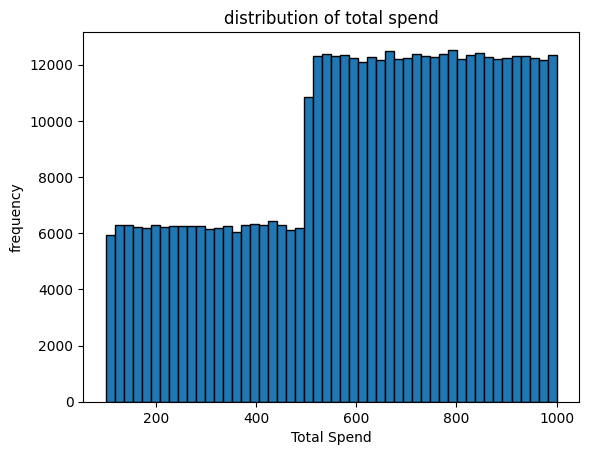

In [ ]:
import matplotlib.pyplot as plt

plt.hist(dataset['Total Spend'].dropna(), bins=50, edgecolor='black')
plt.xlabel('Total Spend')
plt.ylabel('frequency')
plt.title('distribution of total spend')
plt.show()

In [ ]:
print(dataset['Total Spend'].mean())
print(dataset['Total Spend'].median())

619.8413050634863
648.0


Since the histogram shows a bimodal distribution and the skewness value is -0.39, which shows the dataset is slightly lef-skewed and mean is smaller than median, the best option is to replace NaN values with median.

In [ ]:

dataset['Total Spend'].fillna(dataset['Total Spend'].median(), inplace=True)

To handle NaN values in Subscription Type (Categorical), first I checked which category is more common becasue if one category dominates, the best approach is to fill NaN values with this category.

In [ ]:
print(dataset['Subscription Type'].value_counts())


Subscription Type
Standard    162075
Premium     161484
Basic       156387
Name: count, dtype: int64


Since all the categories fairly balanced, I think best idea is to replace NaN values randomly to prevent any bias in the dataset.

In [ ]:
# get the probabilities of each category
category_probs = dataset['Subscription Type'].value_counts(normalize=True)

# replace NaN values
missing_indices = dataset['Subscription Type'].isna()
dataset.loc[missing_indices, 'Subscription Type'] = np.random.choice(
    category_probs.index, size=missing_indices.sum(), p=category_probs.values
)

In [ ]:
dataset.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


As we can see in the above table, the dataset has been cleaned.

Inspect the summary of numerical columns:

In [ ]:
dataset.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000
mean,200779.451782,39.704172,31.350435,15.714825,3.833317,13.496843,621.249223,14.610581,0.555203
std,137241.343095,12.670577,17.237482,8.619323,3.133603,8.451187,239.100275,8.608286,0.496944
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,63827.250000,29.000000,16.000000,8.000000,1.000000,6.000000,464.000000,7.000000,0.000000
50%,193039.500000,40.000000,32.000000,16.000000,3.000000,13.000000,648.000000,14.000000,1.000000
75%,321645.750000,49.000000,46.000000,23.000000,6.000000,20.000000,814.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


As the values of mean and median (50%) were almost the same and max values were not significantly larger than 75%, there were not any potential outliers in this dataset. To confirm that, I used boxplots:

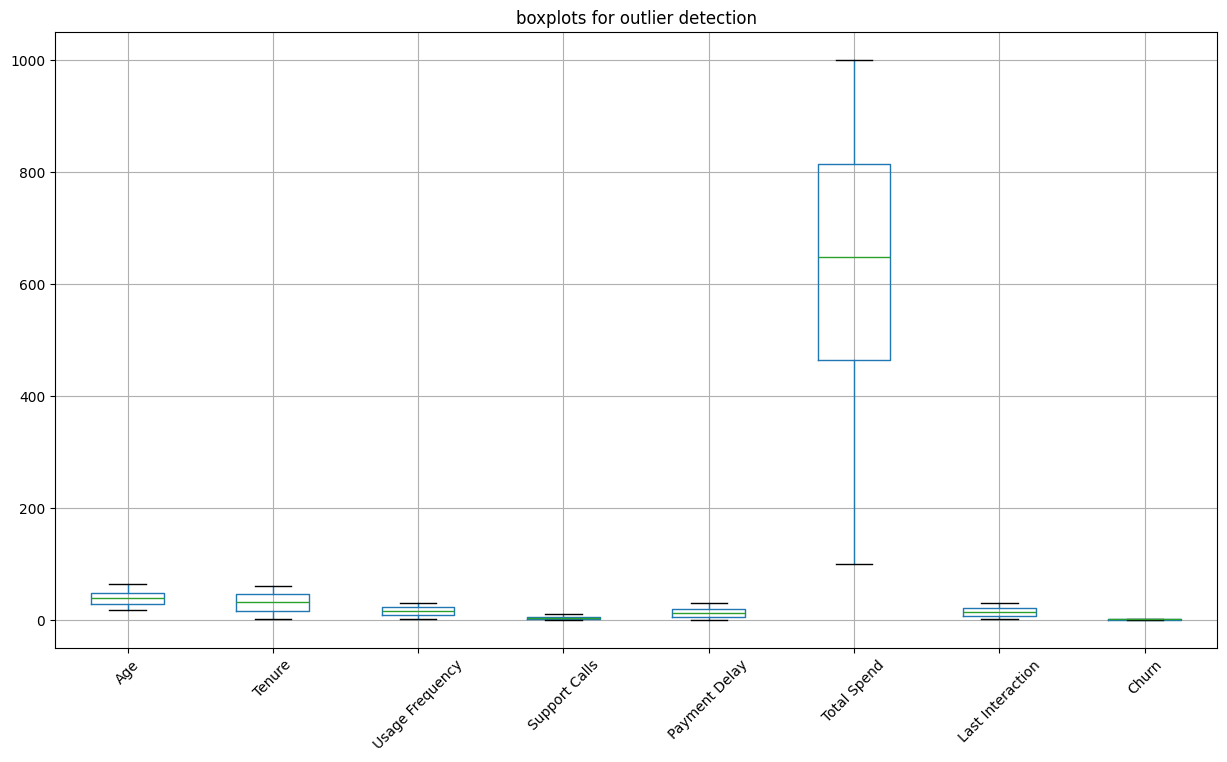

In [ ]:
# select numerical values
numerical_columns = dataset.select_dtypes(include=['int64', 'float64']).columns
numerical_columns = numerical_columns.drop('CustomerID')

# plot boxplots
plt.figure(figsize=(15, 8))
dataset[numerical_columns].boxplot(rot=45)
plt.title('boxplots for outlier detection')
plt.show()

The bxplot suggests possible outliers, especially in Total Spend. To inspect this issue I used IQR to provide numerical insights, it helps us quantify how many values fall outside the expected range.

In [ ]:
# calculate IQR
Q1 = dataset[numerical_columns].quantile(0.25)
Q3 = dataset[numerical_columns].quantile(0.75)
IQR = Q3 - Q1

# lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (dataset[numerical_columns] < lower_bound) | (dataset[numerical_columns] > upper_bound)
outliers_count = outliers.sum()
print('numbr of outliers per column:')
print(outliers_count)

numbr of outliers per column:
Age                 0
Tenure              0
Usage Frequency     0
Support Calls       0
Payment Delay       0
Total Spend         0
Last Interaction    0
Churn               0
dtype: int64


Since the boxplot visually suggested possible outliers, this result seemed unexpected for Total Spend. To inspect it more, I used IQR verification. It helps detect outliers by identifying values that fall outside of 1.5 times the interquartile range (Q1 - 1.5*IQR, Q3 + 1.5*IQR). <br>
I checked Total Spend to confirm if extreme values exist:

In [ ]:
# Q1, Q3, and IQR for Total Spend
Q1_spend = dataset["Total Spend"].quantile(0.25)
Q3_spend = dataset["Total Spend"].quantile(0.75)
IQR_spend = Q3_spend - Q1_spend

# calculate lower and upper bound
lower_bound_spend = Q1_spend - 1.5 * IQR_spend
upper_bound_spend = Q3_spend + 1.5 * IQR_spend

print(f"Q1 (25th percentile) for Total Spend: {Q1_spend}")
print(f"Q3 (75th percentile) for Total Spend: {Q3_spend}")
print(f"IQR for Total Spend: {IQR_spend}")
print(f"lower bound for outliers: {lower_bound_spend}")
print(f"upper bound for outliers: {upper_bound_spend}")

# actual min and max values in Total Spend
actual_min_spend = dataset["Total Spend"].min()
actual_max_spend = dataset["Total Spend"].max()

print(f"actual min value in Total Spend: {actual_min_spend}")
print(f"actual max value in Total Spend: {actual_max_spend}")

Q1 (25th percentile) for Total Spend: 464.0
Q3 (75th percentile) for Total Spend: 814.0
IQR for Total Spend: 350.0
lower bound for outliers: -61.0
upper bound for outliers: 1339.0
actual min value in Total Spend: 100.0
actual max value in Total Spend: 1000.0


Since Total Spend cannot be negative, no values fall below this threshold. Also, the actual maximum value is 1,000, which is below the upper bound. These results showed no outliers, so no modifications were needed.<br><br>
I checked the distribution of the target variable to see if the dataset was imbalanced or not.

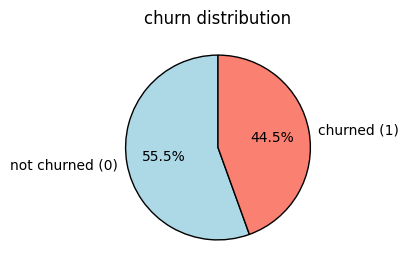

In [ ]:
# plot a pie chart
churn_count = dataset['Churn'].value_counts()

plt.figure(figsize=(3, 3))
plt.pie(churn_count, labels=["not churned (0)", "churned (1)"], autopct='%1.1f%%', colors=["lightblue", "salmon"], startangle=90, wedgeprops={"edgecolor": "black"})
plt.title('churn distribution')
plt.show()

44.5% of customers are churned, and 55.5% are not churned, which means that the dataset is balanced.

In [ ]:
# check which varibales should be binned
for column in numerical_columns:
  print(f"{column}: {dataset[column].nunique()} unique values")

Age: 48 unique values
Tenure: 60 unique values
Usage Frequency: 30 unique values
Support Calls: 11 unique values
Payment Delay: 31 unique values
Total Spend: 901 unique values
Last Interaction: 30 unique values
Churn: 2 unique values


The Age and Tenure variables have 48 and 60 unique values and should be considered for binning. But, the Total Spend is not a good candidate because it removes precise spending differences.

In [ ]:
age_bins = [18, 29, 41, 53, 65]
age_labels = ["18-29", "30-41", "42-53", "54-65"]

tenure_bins = [0, 12, 24, 36, 60]
tenure_labels = ["0-12", "13-24", "25-36", "37-60"]

# apply binning
dataset["Age_Binned"] = pd.cut(dataset["Age"], bins=age_bins, labels=age_labels, include_lowest=True)
dataset["Tenure_Binned"] = pd.cut(dataset["Tenure"], bins=tenure_bins, labels=tenure_labels, include_lowest=True)

# check binning
print(dataset[["Age", "Age_Binned"]].head(10))
print(dataset[["Tenure", "Tenure_Binned"]].head(10))

# drop Age and Tenure
dataset = dataset.drop(columns=['Age', 'Tenure'])

   Age Age_Binned
0   30      30-41
1   65      54-65
2   55      54-65
3   58      54-65
4   23      18-29
5   51      42-53
6   58      54-65
7   55      54-65
8   39      30-41
9   64      54-65
   Tenure Tenure_Binned
0      39         37-60
1      49         37-60
2      14         13-24
3      38         37-60
4      32         25-36
5      33         25-36
6      49         37-60
7      37         37-60
8      12          0-12
9       3          0-12


<h4>Subscription Type vs Churn<h4>

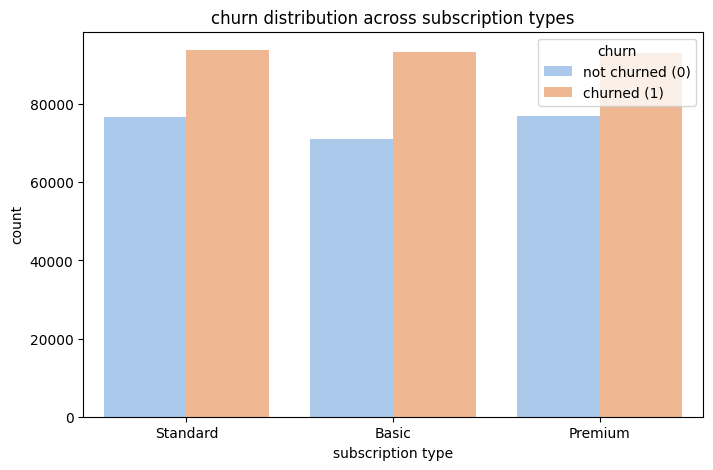

churn rate by subscription type (%):
Subscription Type
Basic       56.780779
Premium     54.801865
Standard    55.021453
Name: Churn, dtype: float64


In [ ]:
import seaborn as sns

# plot the count plt
plt.figure(figsize=(8, 5))
sns.countplot(x="Subscription Type", hue="Churn", data=dataset, palette="pastel")
plt.title("churn distribution across subscription types")
plt.xlabel("subscription type")
plt.ylabel("count")
plt.legend(title="churn", labels=["not churned (0)", "churned (1)"])
plt.show()

# calculate the churn rate for each subscription type
subscription_churn_rate = dataset.groupby("Subscription Type")["Churn"].mean() * 100
print("churn rate by subscription type (%):")
print(subscription_churn_rate)

The churn rate is almost the same for each subscription type; it suggests an overall improvement in customer satisfaction.

<h4>Contract Length vs Churn<h4>

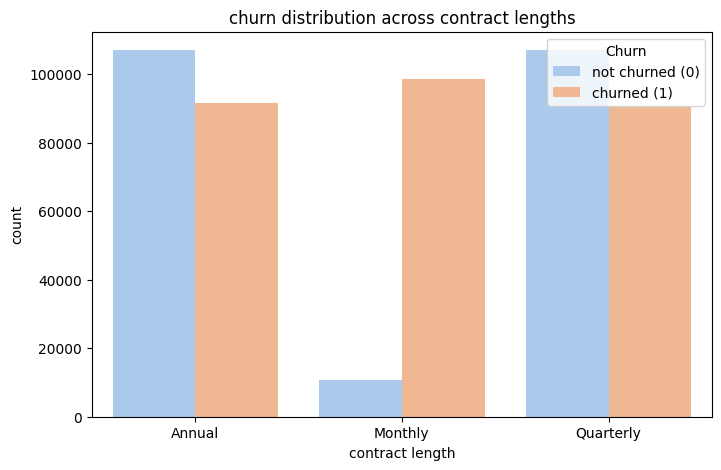

churn rate by contract length (%):
Contract Length
Annual       46.091295
Monthly      90.196276
Quarterly    45.816866
Name: Churn, dtype: float64


In [ ]:
# count plot
plt.figure(figsize=(8, 5))
sns.countplot(x="Contract Length", hue="Churn", data=dataset, palette="pastel")
plt.title("churn distribution across contract lengths")
plt.xlabel("contract length")
plt.ylabel("count")
plt.legend(title="Churn", labels=["not churned (0)", "churned (1)"])
plt.show()

# calculate churn rate for each contract length
contract_churn_rate = dataset.groupby("Contract Length")["Churn"].mean() * 100
print("churn rate by contract length (%):")
print(contract_churn_rate)

Customers with monthly contracts have extremely high churn(90%). This shows that short-term flexibility allows customers to leave easily, and the company needs a strategy to convert them into long-term customers. Annual and quarterly customers have a close churn rate, but they are still considered as high (46%).

<h3>Gender vs Churn<h3>

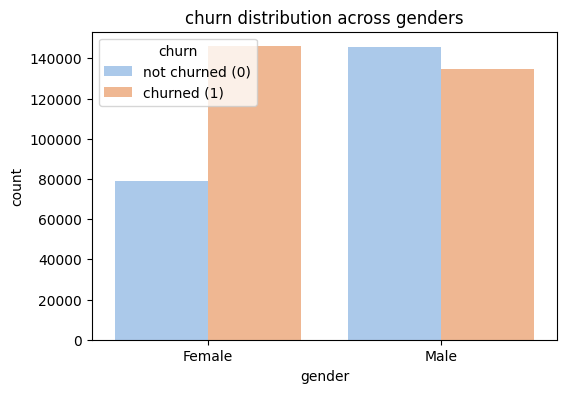

churn rate by gender (%):
Gender
Female    64.894435
Male      47.997131
Name: Churn, dtype: float64


In [ ]:
# count plot
plt.figure(figsize=(6, 4))
sns.countplot(x="Gender", hue="Churn", data=dataset, palette="pastel")
plt.title("churn distribution across genders")
plt.xlabel("gender")
plt.ylabel("count")
plt.legend(title="churn", labels=["not churned (0)", "churned (1)"])
plt.show()

# Calculate churn rate for each gender
gender_churn_rate = dataset.groupby("Gender")["Churn"].mean() * 100
print("churn rate by gender (%):")
print(gender_churn_rate)

While the population of males is larger, the churn rate of females is 19% more than that of males. This suggests that women are more likely to leave.

<h3>Total Spend vs Churn<h3>

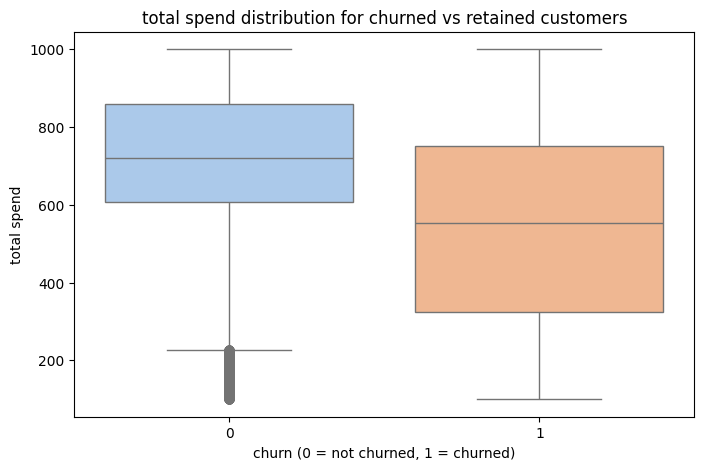

In [ ]:
# boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x="Churn", y="Total Spend", data=dataset, palette="pastel")
plt.title("total spend distribution for churned vs retained customers")
plt.xlabel("churn (0 = not churned, 1 = churned)")
plt.ylabel("total spend")
plt.show()

The median Total Spend for churned customers (500) is lower than for non-churned customers(700). This shows that higher spenders are more likely to stay, meaning they might not find enough value in the service. Non-churned customers have a broader interquartile range (IQR) (600 to 900). Churned customers have a lower IQR (300 to 700), meaning they generally spend less.

<h3>Usage Frequency vs Churn<h3>

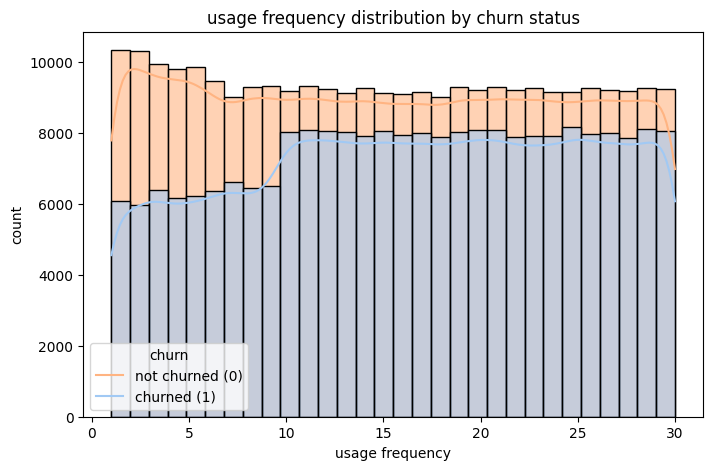

In [ ]:
# plot histogram
plt.figure(figsize=(8, 5))
sns.histplot(data=dataset, x="Usage Frequency", hue="Churn", kde=True, bins=30, palette="pastel", alpha=0.6)
plt.title("usage frequency distribution by churn status")
plt.xlabel("usage frequency")
plt.ylabel("count")
plt.legend(title="churn", labels=["not churned (0)", "churned (1)"])
plt.show()

The highest churn density is concentrated in the low usage range (1-10 times per month), which shows that customers who use the service infrequently are at higher risk of churning.

<h3>Payment Delays vs Churn<h3>

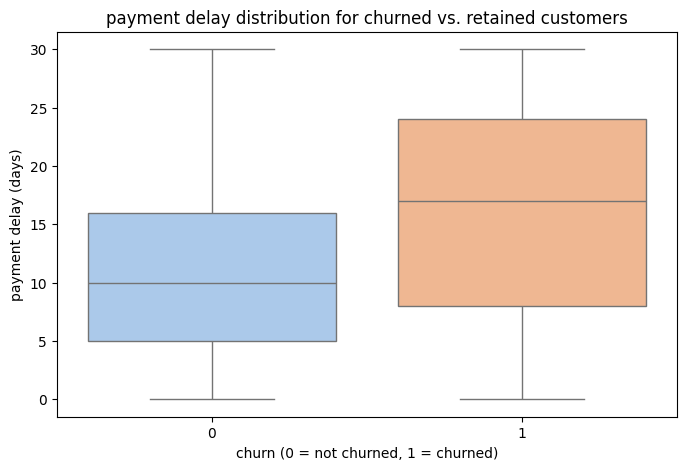

In [ ]:
# boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x="Churn", y="Payment Delay", data=dataset, palette="pastel")
plt.title("payment delay distribution for churned vs. retained customers")
plt.xlabel("churn (0 = not churned, 1 = churned)")
plt.ylabel("payment delay (days)")
plt.show()

The median payment delay for churned customers (17-18 days) is significantly higher than for non-churned customers (10 days), which shows that late payments are a strong indicator of potential churn. Churned customers have a wider interquartile range (IQR) 7 to 25 days, meaning some customers delay payments for extended periods before leaving.

<h3>Usage Frequency + Subscription Type vs Churn<h3>

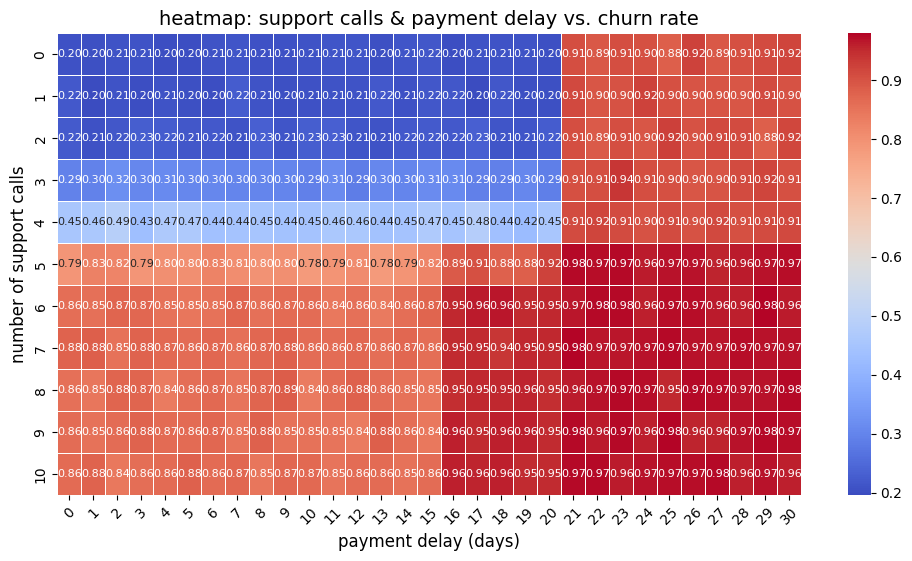

In [ ]:
# pivot table for the heatmap
heatmap_data = dataset.pivot_table(index="Support Calls", columns="Payment Delay", values="Churn", aggfunc="mean")

# plot the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5, annot_kws={"size": 8})
plt.title("heatmap: support calls & payment delay vs. churn rate", fontsize=14)
plt.xlabel("payment delay (days)", fontsize=12)
plt.ylabel("number of support calls", fontsize=12)
plt.xticks(rotation=45)
plt.show()

Customers with frequent support calls (+5) and long payment delays (+15) are at the highest risk of churn. While timely payments and fewer support calls correlate with higher retention (20 to 30% churn).

<h3>Correlation Analysis<h3>

To determine which numerical features most strongly impact churn, I calculated and analysed the correlation values:

correlation of numerical features with churn:
Churn               1.000000
Support Calls       0.516283
Payment Delay       0.329785
Last Interaction    0.127150
Usage Frequency    -0.053263
Total Spend        -0.359313
CustomerID         -0.650617
Name: Churn, dtype: float64


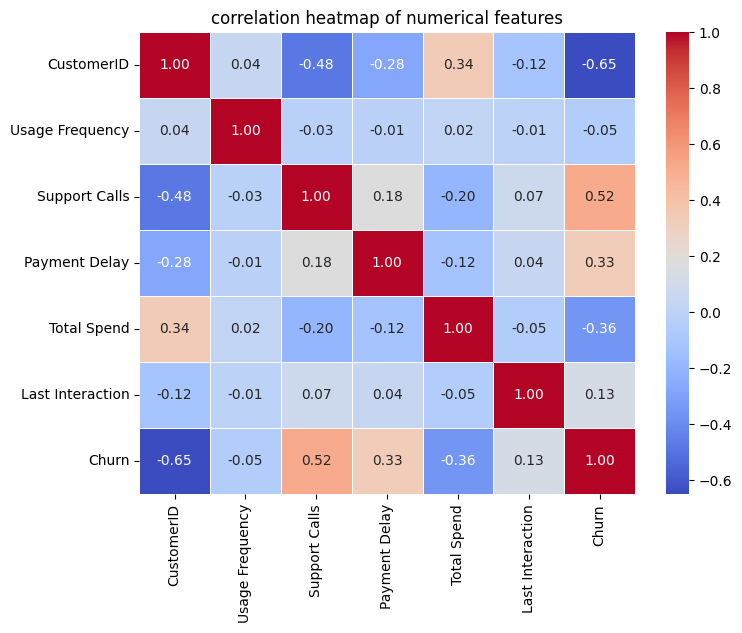

In [ ]:
# select numerical columns
numerical_columns = dataset.select_dtypes(include=["int64", "float64"])

# correlation matrix
correlation_matrix = numerical_columns.corr()
churn_correlation = correlation_matrix["Churn"].sort_values(ascending=False)
print("correlation of numerical features with churn:")
print(churn_correlation)

# plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("correlation heatmap of numerical features")
plt.show()

As we see in the heatmap, some variables are not a strong predictor for churn. But before drop them, I tried to create new features and re-run the correlation analysis.

Support Calls (0.52) and Payment Delay (0.33) were two of the strongest churn predictors, meaning that a customer who makes frequent support calls AND delays payments is a high-risk churner. So, I created a new feature called Issue Severity Score (Support Calls * Payment Delay) to capture customers who both complain a lot AND have late payments.

In [ ]:
dataset['Issue Severity'] = dataset['Support Calls'] * dataset['Payment Delay']

In usage frequency distribution by churn status histogram, a clear threshold (+10) for Payment Delay was seen in churn patterns. Instead of using raw Payment Delay, I converted it to a categorical flag. Customers who regularly pay late may be at high churn risk. Turning it into 0 or 1 makes it easier for models to learn.

In [ ]:
dataset["Late Payer"] = (dataset["Payment Delay"] > 10).astype(int)

Usage Frequency was a weak predictor (-0.05) on its own, but when combined with Support Calls, it might be stronger. Customers who use the service frequently AND complain often may have expectations that are not being met. If the score is low, they might be low-value customers who are disengaged.

In [ ]:
dataset["Engagement Score"] = dataset["Usage Frequency"] * dataset["Support Calls"]

To measure how often a customer engages compared to how late they pay, instead of just looking at Usage Frequency, I divided it by Payment Delay. A high score means the customer uses the service a lot despite late payments, meaning they might stay. A low score means the customer is not using the service and also paying late means a higher churn risk.

In [ ]:
# +1 to avoid disvisoin by zero
dataset["Payment Behavior"] = dataset["Usage Frequency"] / (dataset["Payment Delay"] + 1)

Frequent support calls in a short period might mean urgent dissatisfaction and lead to churn. Instead of raw Support Calls, I normalised it by the time since the last interaction. If a customer contacts support often but has not interacted much recently, they might have given up on the service.

In [ ]:
dataset["Support Call Rate"] = dataset["Support Calls"] / (dataset["Last Interaction"] + 1)

Re-run the correlation analysis to check if these new features are better predictors.

correlation of numerical features with churn (after feature engineering):
Churn                1.000000
Support Calls        0.516283
Issue Severity       0.470710
Engagement Score     0.368929
Payment Delay        0.329785
Support Call Rate    0.253017
Late Payer           0.199707
Last Interaction     0.127150
Usage Frequency     -0.053263
Payment Behavior    -0.125995
Total Spend         -0.359313
CustomerID          -0.650617
Name: Churn, dtype: float64


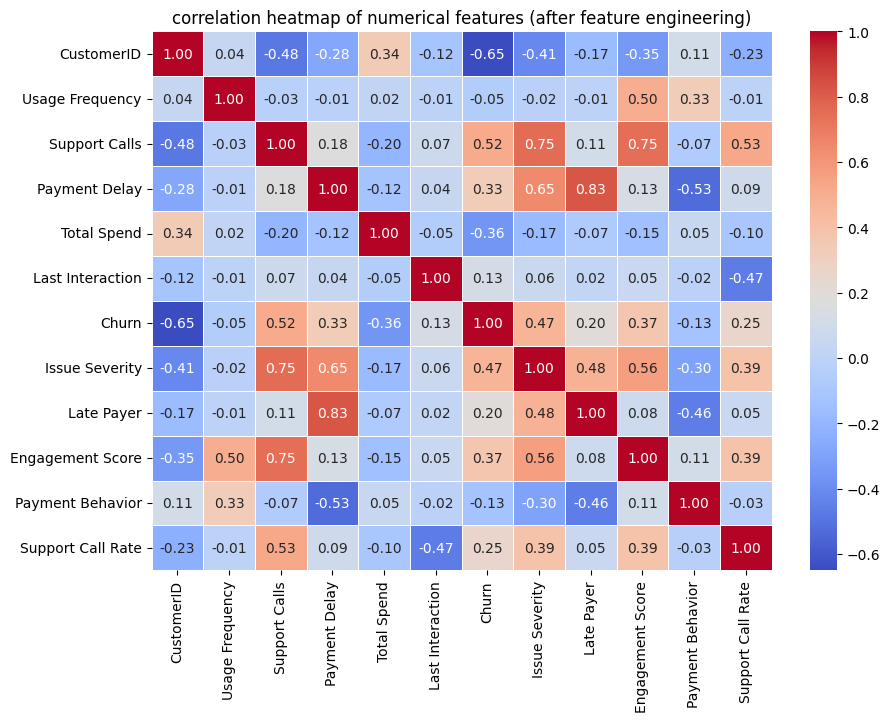

In [ ]:
numerical_columns = dataset.select_dtypes(include=["int64", "float64"])
correlation_matrix = numerical_columns.corr()

churn_correlation = correlation_matrix["Churn"].sort_values(ascending=False)
print("correlation of numerical features with churn (after feature engineering):")
print(churn_correlation)

plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("correlation heatmap of numerical features (after feature engineering)")
plt.show()

As we see in the heatmap, the new features are strong predictors, except Payment Behavior. So, I set a threshold (-+0.25) to only select strong predictors for model development.

In [ ]:
selected_features = [
    'Gender', 'Subscription Type', 'Contract Length', 'Age_Binned', 'Tenure_Binned',
    'Support Calls', 'Support Call Rate', 'Issue Severity', 'Payment Delay',
    'Engagement Score', 'Total Spend', 'Churn'
]

final_dataset = dataset[selected_features]

In [ ]:
final_dataset.head()

,Gender,Subscription Type,Contract Length,Age_Binned,Tenure_Binned,Support Calls,Support Call Rate,Issue Severity,Payment Delay,Engagement Score,Total Spend,Churn
0,Female,Standard,Annual,30-41,37-60,5,0.277778,90,18,70,932.0,1
1,Female,Basic,Monthly,54-65,37-60,10,1.428571,80,8,10,557.0,1
2,Female,Basic,Quarterly,54-65,13-24,6,1.500000,108,18,24,185.0,1
3,Male,Standard,Monthly,54-65,37-60,7,0.233333,49,7,147,396.0,1
4,Male,Basic,Monthly,18-29,25-36,5,0.238095,40,8,100,617.0,1


<h3>Normalisation and Encoding<h3>

I separated categorical and numerical columns, converted them and then combined them.</br>
I chose one-hot encoding for unordered categorical columns and label encoding for ordinal ones.

In [ ]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

categorical_features = ['Gender', 'Subscription Type', 'Contract Length']
ordinal_features = ['Age_Binned', 'Tenure_Binned']

# one-hot encoding
one_hot_encoding = OneHotEncoder(drop="first", sparse_output=False)
encoded_categorical = one_hot_encoding.fit_transform(final_dataset[categorical_features])
encoded_categorical_dataset = pd.DataFrame(encoded_categorical, columns=one_hot_encoding.get_feature_names_out(categorical_features))

# label encoding
label_encoder = LabelEncoder()
encoded_ordinal_dataset = final_dataset[ordinal_features].apply(label_encoder.fit_transform)

# combine encoded data
encoded_dataset = pd.concat([encoded_categorical_dataset, encoded_ordinal_dataset], axis=1)

Normalised numerical features using Standardization (Z-score Scaling).

In [ ]:
from sklearn.preprocessing import StandardScaler

numerical_features = ["Support Calls", "Issue Severity", "Engagement Score", "Payment Delay", "Support Call Rate", 'Total Spend']

# normalisation
scaler = StandardScaler()
normalised_numerical = scaler.fit_transform(final_dataset[numerical_features])

# convert to a data frame
normalised_numerical_dataset = pd.DataFrame(normalised_numerical, columns=numerical_features)

In [ ]:
# combine 2 dataset (encoded and normalised)
clean_dataset = pd.concat([encoded_dataset, normalised_numerical_dataset, final_dataset['Churn'].reset_index(drop=True)], axis=1)
clean_dataset.head()

,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly,Age_Binned,Tenure_Binned,Support Calls,Issue Severity,Engagement Score,Payment Delay,Support Call Rate,Total Spend,Churn
0,0.0,0.0,1.0,0.0,0.0,1,3,0.372314,0.504228,0.162137,0.532844,-0.202308,1.299668,1
1,0.0,0.0,0.0,1.0,0.0,3,3,1.967923,0.354161,-0.767824,-0.650423,1.738363,-0.268713,1
2,0.0,0.0,0.0,0.0,1.0,3,1,0.691436,0.774347,-0.550833,0.532844,1.858819,-1.824547,1
3,1.0,0.0,1.0,1.0,0.0,3,3,1.010558,-0.111043,1.355587,-0.768750,-0.277258,-0.942071,1
4,1.0,0.0,0.0,1.0,0.0,0,2,0.372314,-0.246103,0.627118,-0.650423,-0.269227,-0.017772,1


<h2>Model Development<h2>

I tested several traditional machine learning models (Logistic Regression, Decision Tree, Random Forest, XGBoost, and SVM). While these models performed well, they rely on handcrafted features and may struggle to capture complex patterns in the data. Deep learning models like MLP can automatically learn feature interactions, making them ideal for structured data. Unlike tree-based models, MLP does not rely on splitting criteria, allowing it to capture non-linear relationships more effectively.  MLP provides flexibility in architecture, allowing us to experiment with hidden layers, activation functions, and optimisers for the best performance.<br>
Hidden layers use ReLU as an activation function to prevent vanishing gradients. The output layer uses the Sigmoid activation function because it is suitable for classification tasks. Also, I choose Cross-Entropy Loss to measure the difference between predicted probability and actual class, and it is the best choice for classification problems.<br>

After I developed a basic model and it was successful, I ran a grid search to find the best hyperparameters. But, due to the computational resources, I ran a random grid search on limited hyperparameters, including hidden layers, learning rates, epochs, optimiser, hidden layer size, dropout rate and batch size.

<h3>The analysis of the result of MLP is in the report<h3>

<h3>The grid search is computationally expensive, and it takes 30 minutes with A100 GPU, to run the code just for one combination just simply change the hyperparameters as follows to get the best result:<h3>

Learning Rate= 0.0001,
Batch Size = 32,
Hidden Size = 256,
Number of Epochs = 20,
Optimiser = Adam,
Dropout Rate = 0.3


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import itertools
import random
from sklearn.metrics import accuracy_score
# create the MLP model
class MLP(nn.Module):
  def __init__(self, input_size, hidden_size, dropout_rate=0.3):
    super(MLP, self).__init__()

    # define hidden layers
    self.fc1 = nn.Linear(input_size, hidden_size)
    self.fc2 = nn.Linear(hidden_size, 64)

    # define output layer
    self.output = nn.Linear(64, 1)

    # activation functions
    self.relu = nn.ReLU()
    self.sigmoid = nn.Sigmoid()
    self.dropout = nn.Dropout(dropout_rate) # dropout

    # forward pass
  def forward(self, x):
    x = self.relu(self.fc1(x))
    x = self.dropout(x)
    x = self.relu(self.fc2(x))
    x = self.dropout(x)
    return self.sigmoid(self.output(x))

# define features and target variable
X = clean_dataset.drop('Churn', axis=1).values
y = clean_dataset['Churn'].values

# convert to tensor
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

# split the dataset (training=60%, validation=20%, testing=20%)
X_temp, X_test, y_temp, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=10)
X_train, X_validation, y_train, y_validation = train_test_split(X_temp, y_temp, test_size=0.25, random_state=10)

# create datasets
train_dataset = TensorDataset(X_train, y_train)
validation_dataset = TensorDataset(X_validation, y_validation)
test_dataset = TensorDataset(X_test, y_test)

# define hyperparameters (change this)
parameters_MLP = {
    'learning_rate': [0.0001, 0.001, 0.01],
    'batch_size': [32, 64, 128],
    'hidden_size': [64, 128, 256],
    'epochs': [10, 20, 30],
    'optimiser': ['Adam', 'SGD', 'AdamW'],
    'dropout_rate': [0.2, 0.3, 0.5]
}

# generate all combination of parameters
hyperparameters_combo = list(itertools.product(
    parameters_MLP['learning_rate'],
    parameters_MLP['batch_size'],
    parameters_MLP['hidden_size'],
    parameters_MLP['epochs'],
    parameters_MLP['optimiser'],
    parameters_MLP['dropout_rate']
))

# randomly select 10 combinations of hyperparameters for the grid search
selected_combinations = random.sample(hyperparameters_combo, 10)

# define variables to track the best model
best_validation_accuracy = 0
best_model_state = None
best_hyperparameters = None

# run the grid search
for lr, batch_size, hidden_size, epochs, optimiser_name, dropout_rate in selected_combinations:
  print(f"Training combination: lr={lr}, batch size={batch_size}, hidden={hidden_size}, epochs={epochs}, optimiser={optimiser_name}, dropout rate={dropout_rate}")

  # create dataloaders
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
  validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

  # initialise the model, criterion and optimiser
  model = MLP(input_size=X_train.shape[1], hidden_size=hidden_size, dropout_rate=dropout_rate)
  criterion = nn.BCELoss()
  if optimiser_name == 'Adam':
        optimiser = optim.Adam(model.parameters(), lr=lr)
  elif optimiser_name == 'SGD':
        optimiser = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
  elif optimiser_name == 'AdamW':
        optimiser = optim.AdamW(model.parameters(), lr=lr)

  # track losses and accuracies to plot learning curves
  train_losses = []
  validation_losses = []
  train_accuracies = []
  validation_accuracies = []

  # training
  for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    correct_train = 0
    total_train = 0

    for X_batch, y_batch in train_loader:
      optimiser.zero_grad()
      outputs = model(X_batch)
      loss = criterion(outputs, y_batch)
      loss.backward()
      optimiser.step()
      epoch_loss += loss.item()

      predictions = (outputs > 0.5).float()
      correct_train += (predictions == y_batch).sum().item()
      total_train += y_batch.size(0)

    train_losses.append(epoch_loss / len(train_loader))
    train_accuracies.append(correct_train / total_train)

    # calculate validation accuracy per epoch
    model.eval()
    validation_loss = 0
    correct_validation = 0
    total_validation = 0

    with torch.no_grad():
      for X_batch, y_batch in validation_loader:
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        validation_loss += loss.item()

        predictions = (outputs > 0.5).float()
        correct_validation += (predictions == y_batch).sum().item()
        total_validation += y_batch.size(0)

    validation_losses.append(validation_loss / len(validation_loader))
    validation_accuracies.append(correct_validation / total_validation)

  # final validation to track the best model
  validation_predictions = []
  validation_targets = []
  model.eval()
  with torch.no_grad():
    for X_batch, y_batch in validation_loader:
      outputs = model(X_batch)
      predictions = (outputs > 0.5).float()
      validation_predictions.extend(predictions.numpy())
      validation_targets.extend(y_batch.numpy())

  validation_accuracy = accuracy_score(validation_targets, validation_predictions)

  # save the best model and hyperparameters
  if validation_accuracy > best_validation_accuracy:
    best_validation_accuracy = validation_accuracy
    best_model_state = model.state_dict()
    best_hyperparameters = {
        'learning_rate': lr,
        'batch_size': batch_size,
        'hidden_size': hidden_size,
        'epochs': epochs,
        'optimiser': optimiser_name,
        'dropout_rate': dropout_rate,
        'train_losses': train_losses,
        'validation_losses': validation_losses,
        'train_accuracies': train_accuracies,
        'validation_accuracies': validation_accuracies
    }

torch.save(best_model_state, '/content/drive/MyDrive/Colab Notebooks/AI_CW_1/best_model.pth')
print('Best model saved!')

Training combination: lr=0.01, batch size=64, hidden=64, epochs=20, optimiser=Adam, dropout rate=0.3
Training combination: lr=0.01, batch size=64, hidden=64, epochs=20, optimiser=Adam, dropout rate=0.2
Training combination: lr=0.001, batch size=64, hidden=64, epochs=20, optimiser=SGD, dropout rate=0.5
Training combination: lr=0.0001, batch size=128, hidden=64, epochs=10, optimiser=Adam, dropout rate=0.5
Training combination: lr=0.01, batch size=128, hidden=256, epochs=10, optimiser=AdamW, dropout rate=0.3
Training combination: lr=0.0001, batch size=64, hidden=256, epochs=10, optimiser=SGD, dropout rate=0.2
Training combination: lr=0.0001, batch size=32, hidden=64, epochs=20, optimiser=Adam, dropout rate=0.5
Training combination: lr=0.001, batch size=32, hidden=128, epochs=10, optimiser=SGD, dropout rate=0.5
Training combination: lr=0.0001, batch size=32, hidden=128, epochs=30, optimiser=Adam, dropout rate=0.2
Training combination: lr=0.01, batch size=128, hidden=64, epochs=30, optimise

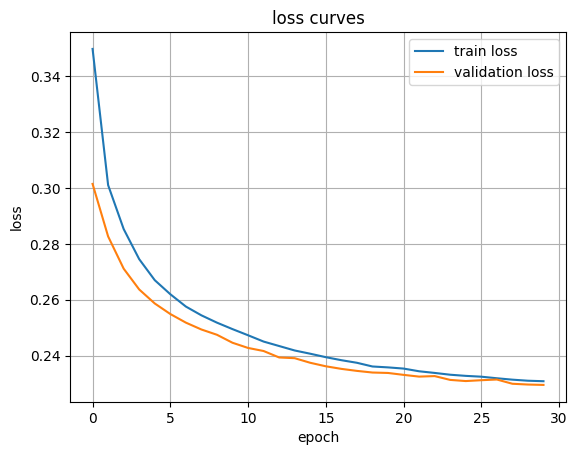

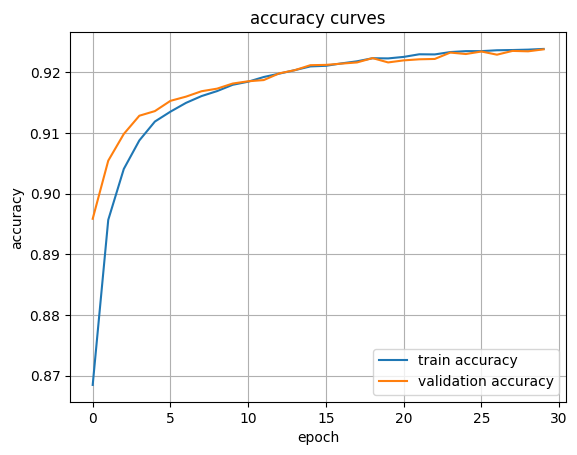

In [ ]:
# plot learning curves
plt.plot(best_hyperparameters['train_losses'], label='train loss')
plt.plot(best_hyperparameters['validation_losses'], label='validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('loss curves')
plt.legend()
plt.grid(True)
plt.show()

plt.plot(best_hyperparameters['train_accuracies'], label='train accuracy')
plt.plot(best_hyperparameters['validation_accuracies'], label='validation accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('accuracy curves')
plt.legend()
plt.grid(True)
plt.show()

accuracy: 0.9254
precision: 0.8971
recall: 0.9775
F1 score: 0.9356


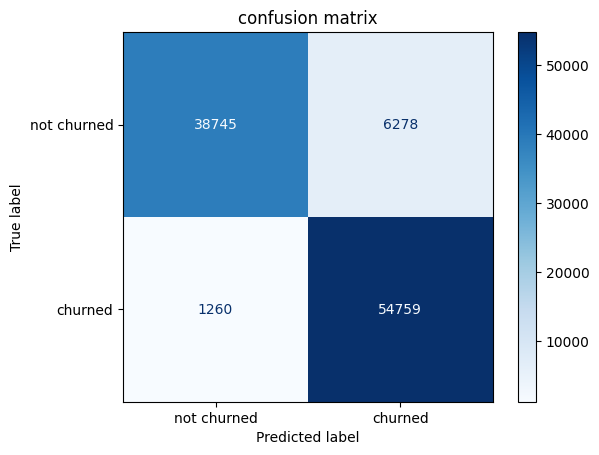

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# load and evaluate the best model
best_model = MLP(input_size=X.shape[1], hidden_size=best_hyperparameters['hidden_size'], dropout_rate=best_hyperparameters['dropout_rate'])
best_model.load_state_dict(best_model_state)
best_model.eval()

# craeate test loaders
test_loader = DataLoader(test_dataset, batch_size=best_hyperparameters['batch_size'], shuffle=False)
test_predictions = []
test_targets = []

with torch.no_grad():
  for X_batch, y_batch in test_loader:
    outputs = best_model(X_batch)
    predictions = (outputs > 0.5).float()
    test_predictions.extend(predictions.numpy())
    test_targets.extend(y_batch.numpy())

accuracy = accuracy_score(test_targets, test_predictions)
precision = precision_score(test_targets, test_predictions)
recall = recall_score(test_targets, test_predictions)
f1 = f1_score(test_targets, test_predictions)

print(f'accuracy: {accuracy:.4f}')
print(f'precision: {precision:.4f}')
print(f'recall: {recall:.4f}')
print(f'F1 score: {f1:.4f}')

confusion_m = confusion_matrix(test_targets, test_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_m, display_labels=['not churned', 'churned'])
disp.plot(cmap=plt.cm.Blues)
plt.title('confusion matrix')
plt.show()

In [ ]:
print("best hyperparameters:")
for key, value in best_hyperparameters.items():
    if key not in ['train_losses', 'validation_losses', 'train_accuracies', 'validation_accuracies']:
        print(f"{key}: {value}")

best hyperparameters:
learning_rate: 0.0001
batch_size: 32
hidden_size: 128
epochs: 30
optimiser: Adam
dropout_rate: 0.2
